# Explainable DR Classification Notebook


In [1]:
# Optional (Colab): Drive shortcut other team members
# 1. In Google Drive, open shared folder 'ITPG708Project'.
# 2. Click 'Add shortcut to Drive' -> choose 'My Drive'.
# 3. If Colab says Drive is already mounted, use force_remount=True and rerun this cell.

from pathlib import Path
import os

def _is_project_root(candidate: Path) -> bool:
    return (
        (candidate / 'requirements.txt').exists()
        and (candidate / 'configs' / 'base.yaml').exists()
        and (candidate / 'src' / 'data.py').exists()
    )

try:
    from google.colab import drive

    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/ITPG708Project')
    if not _is_project_root(BASE_DIR):
        raise FileNotFoundError(
            "Project folder not found at /content/drive/MyDrive/ITPG708Project.\n"
            "Add shared-folder shortcut to My Drive, then remount and rerun this cell."
        )
    os.chdir(BASE_DIR)
    print('Colab working directory:', os.getcwd())
except ImportError:
    print('Not running in Colab. Skip this cell and run Section 1 setup.')


Not running in Colab. Skip this cell and run Section 1 setup.


## 1. Environment Setup


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    load_project_config,
    notebook_prepare_data_overview,
)
from src.train import (
    clean_generated_outputs,
    notebook_run_training,
    notebook_run_core_evaluation,
)
from src.xai import (
    notebook_run_xai,
    notebook_load_xai_committee_summary,
    notebook_load_xai_advanced_audit,
    notebook_run_visual_review,
    notebook_run_single_case_report,
)

display(Markdown(f'**Project root:** `{PROJECT_ROOT}`'))


**Project root:** `/Users/sthabit/My Drive/ITPG708Project`

## 2. Run Configuration


In [3]:
CONFIG_PATH = str((PROJECT_ROOT / 'configs/base.yaml').resolve())
SEED = 1988
EVAL_SPLIT = 'test'
RUN_CLEAN_BEFORE_START = False
FORCE_RETRAIN = False
XAI_SAFE_MODE = False
SHOW_ADVANCED_XAI_AUDIT = False
XAI_VIS_SAFE_MODE = False
XAI_SINGLE_SAFE_MODE = False

cfg = load_project_config(CONFIG_PATH)
protocol = str(cfg.get('data', {}).get('protocol', 'default'))

display(Markdown(f'**Config:** `{CONFIG_PATH}`'))
display(Markdown(
    f'**Protocol:** `{protocol}` | **Seed:** `{SEED}` | **Split:** `{EVAL_SPLIT}` | '
    f'**Backbone:** `{cfg["training"].get("backbone", "resnet50")}`'
))

if protocol == 'benchmark':
    display(Markdown(
        f'**Benchmark split setup:** test_ratio={cfg["data"].get("profile_test_ratio", cfg["data"].get("test_ratio", 0.15)):.2f}, '
        f'val_within_train={cfg["data"].get("profile_val_ratio_within_train", cfg["data"].get("val_ratio", 0.10)):.2f}'
    ))
    display(Markdown(f'**Split seeds:** `{cfg["data"].get("split_seed_list", [SEED])}`'))
else:
    display(Markdown(
        f'**Configured split ratios:** train={cfg["data"]["train_ratio"]:.2f}, '
        f'test={cfg["data"]["test_ratio"]:.2f}, val={cfg["data"]["val_ratio"]:.2f}'
    ))

display(Markdown(
    f'**Preprocessing:** `{cfg.get("preprocessing", {}).get("enabled", True)}` | '
    f'**Loss:** `{cfg["training"].get("loss_name", "auto")}` | '
    f'**Weighted sampler:** `{cfg["training"].get("use_weighted_sampler", True)}` | '
    f'**Force retrain:** `{FORCE_RETRAIN}`'
))

display(Markdown('**Note:** If `RUN_CLEAN_BEFORE_START=True`, checkpoints are deleted first; retraining is expected even when `FORCE_RETRAIN=False`.'))


**Config:** `/Users/sthabit/My Drive/ITPG708Project/configs/base.yaml`

**Protocol:** `benchmark` | **Seed:** `1988` | **Split:** `test` | **Backbone:** `efficientnet_b4`

**Benchmark split setup:** test_ratio=0.15, val_within_train=0.10

**Split seeds:** `[1988, 42, 2026]`

**Preprocessing:** `True` | **Loss:** `focal` | **Weighted sampler:** `False` | **Force retrain:** `False`

**Note:** If `RUN_CLEAN_BEFORE_START=True`, checkpoints are deleted first; retraining is expected even when `FORCE_RETRAIN=False`.

## 3. Optional Output Reset


In [4]:
if RUN_CLEAN_BEFORE_START:
    clean_generated_outputs(CONFIG_PATH)
    print('Generated outputs cleaned.')
else:
    print('Cleanup skipped.')


Cleanup skipped.


## 4. Data Preparation


### Manifest Files

,path
full_data,/Users/sthabit/My Drive/ITPG708Project/artifac...
test_full,/Users/sthabit/My Drive/ITPG708Project/artifac...
train_split,/Users/sthabit/My Drive/ITPG708Project/artifac...
val_split,/Users/sthabit/My Drive/ITPG708Project/artifac...


### Split Sizes

,split,rows,percentage
0,train,2800,76.46%
1,val,312,8.52%
2,test,550,15.02%


### Overall Class Proportions

,class_id,count,class_name,overall_pct
0,0,1805,No_DR,49.29%
1,1,370,Mild,10.10%
2,2,999,Moderate,27.28%
3,3,193,Severe,5.27%
4,4,295,Proliferate_DR,8.06%


### Source Dataset Mix (Roboflow vs APTOS)

,view,source_dataset,rows,view_total,view_pct
0,test,aptos2019,550,550,100.00%
1,train,aptos2019,2800,2800,100.00%
2,val,aptos2019,312,312,100.00%


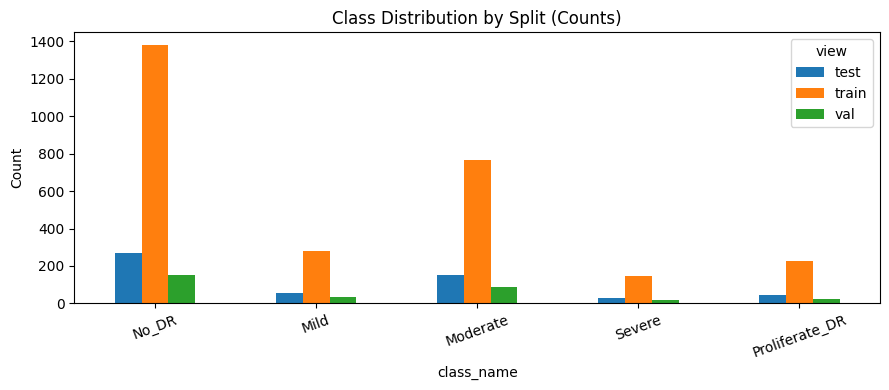

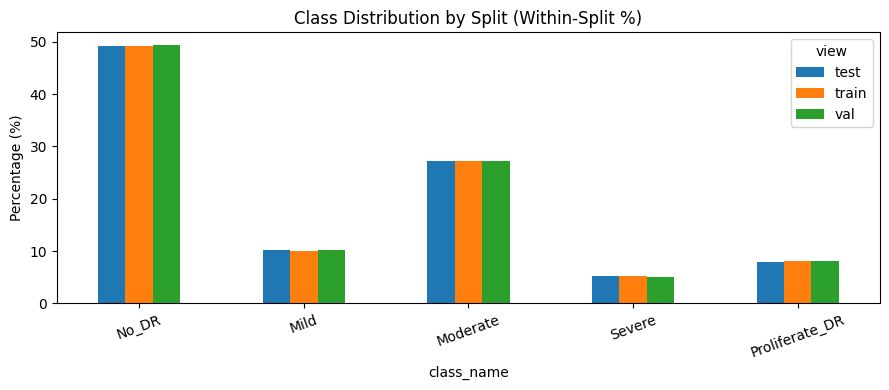

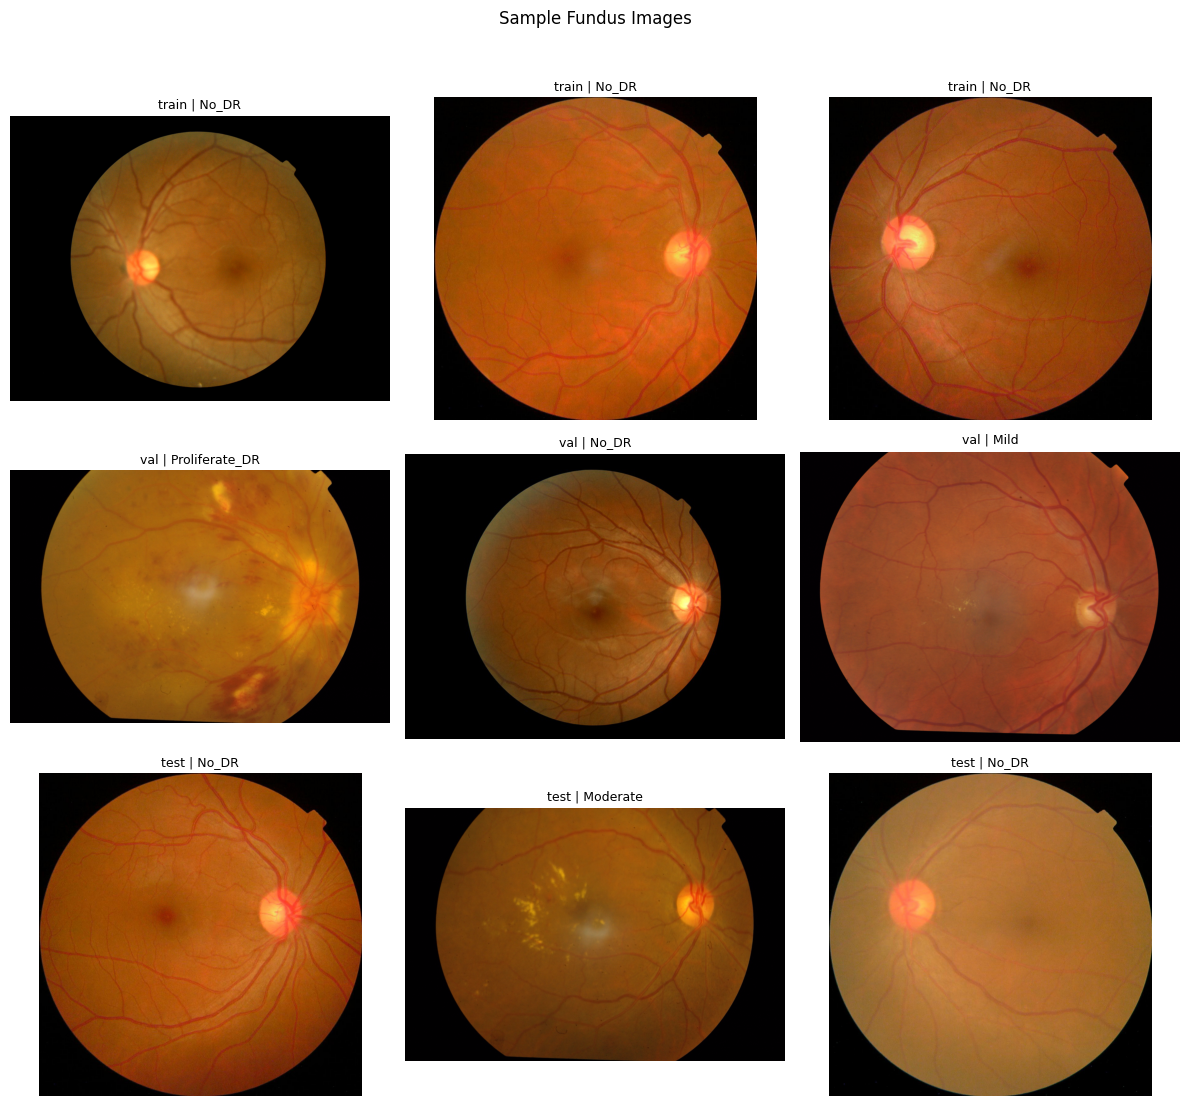

In [5]:
data_overview = notebook_prepare_data_overview(cfg, seed=SEED, samples_per_split=3)
manifest_paths = data_overview['manifest_paths']
train_df = data_overview['train_df']
val_df = data_overview['val_df']
test_df = data_overview['test_df']

display(Markdown('### Manifest Files'))
display(pd.DataFrame([manifest_paths]).T.rename(columns={0: 'path'}))

display(Markdown('### Split Sizes'))
display(data_overview['split_summary'])

display(Markdown('### Overall Class Proportions'))
display(data_overview['overall_class_proportions'])

if len(data_overview['source_dataset_mix']):
    display(Markdown('### Source Dataset Mix (Roboflow vs APTOS)'))
    display(data_overview['source_dataset_mix'])
else:
    display(Markdown('### Source Dataset Mix'))
    display(Markdown('`source_dataset` column not found in manifests.'))

display(data_overview['class_count_fig'])
plt.close(data_overview['class_count_fig'])

display(data_overview['class_proportion_fig'])
plt.close(data_overview['class_proportion_fig'])


## 5. Model Fine-Tuning


Reusing existing checkpoint: /Users/sthabit/My Drive/ITPG708Project/artifacts/checkpoints/dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e.pt


Checkpoint path: `/Users/sthabit/My Drive/ITPG708Project/artifacts/checkpoints/dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e.pt`

Run ID: `dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e`

**Checkpoint reuse:** `True` | **Reason:** `matched_signature`

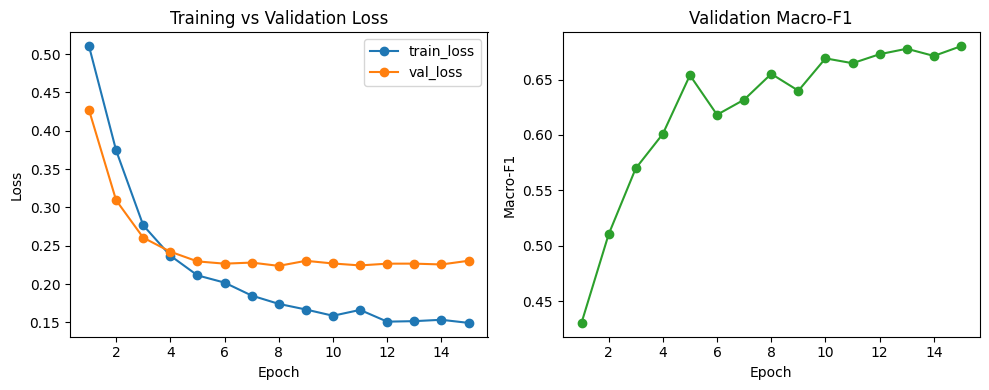

In [6]:
training_out = notebook_run_training(
    cfg,
    seed=SEED,
    manifests=manifest_paths,
    force_retrain=FORCE_RETRAIN,
)
checkpoint_path = training_out['checkpoint_path']
RUN_ID = str(training_out['run_id'])

display(Markdown(f'Checkpoint path: `{checkpoint_path}`'))
display(Markdown(f'Run ID: `{RUN_ID}`'))
display(Markdown(
    f"**Checkpoint reuse:** `{training_out['reused_checkpoint']}` | "
    f"**Reason:** `{training_out['reuse_reason']}`"
))


## 6. Model Evaluation


**Predictions used for evaluation:** `/Users/sthabit/My Drive/ITPG708Project/artifacts/predictions/dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e_test_predictions.csv`

### Evaluation Output Files

,path
metrics,/Users/sthabit/My Drive/ITPG708Project/artifac...
final_headline_metrics,/Users/sthabit/My Drive/ITPG708Project/artifac...
confusion,/Users/sthabit/My Drive/ITPG708Project/artifac...
per_class,/Users/sthabit/My Drive/ITPG708Project/artifac...
run_summary,/Users/sthabit/My Drive/ITPG708Project/artifac...


### Overall Metrics + Run Summary

,run_id,accuracy,precision_macro,recall_macro,f1_macro,split,n_all,qwk_all,n_high_conf,accuracy_high_conf,qwk_high_conf
0,dr_efficientnet_b4_aptos2019_85-15-v10_seed198...,0.821818,0.710352,0.740778,0.710542,test,550,0.895752,550,0.821818,0.895752


### Per-Class Metrics

,class_id,class_name,support,precision,recall,sensitivity,specificity,f1
0,0,No_DR,271,0.981343,0.970480,0.970480,0.982079,0.975881
1,1,Mild,56,0.513158,0.696429,0.696429,0.925101,0.590909
2,2,Moderate,150,0.804688,0.686667,0.686667,0.937500,0.741007
3,3,Severe,29,0.510638,0.827586,0.827586,0.955854,0.631579
4,4,Proliferate_DR,44,0.741935,0.522727,0.522727,0.984190,0.613333


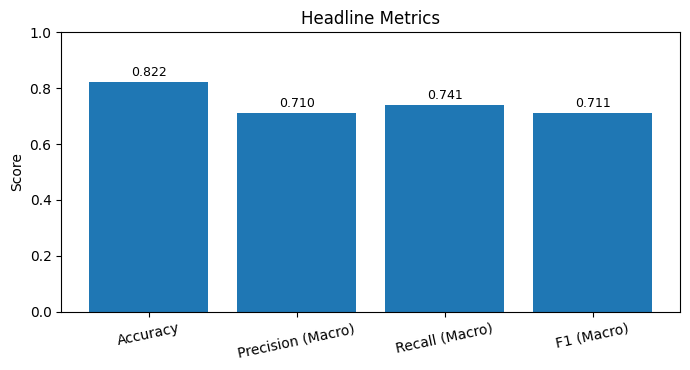

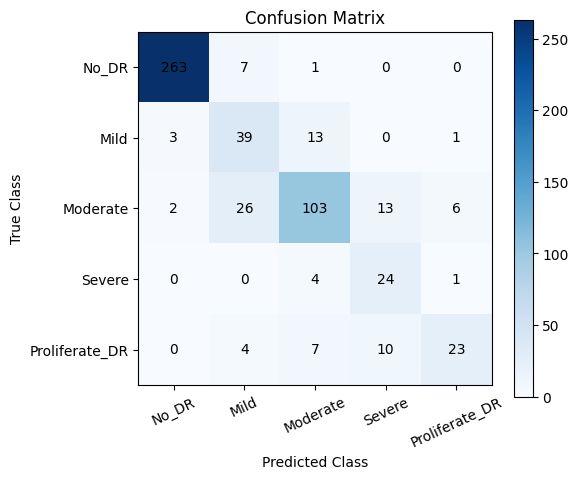

In [7]:
core_eval = notebook_run_core_evaluation(
    cfg,
    seed=SEED,
    split=EVAL_SPLIT,
)

display(Markdown(f'**Predictions used for evaluation:** `{core_eval["predictions_path"]}`'))
display(Markdown('### Evaluation Output Files'))
display(core_eval['eval_output_paths_df'])

display(Markdown('### Overall Metrics + Run Summary'))
display(core_eval['overall_summary_df'])

display(Markdown('### Per-Class Metrics'))
display(core_eval['per_class_df'])


## 7. Explainability Analysis (Grad-CAM + SHAP)


In [8]:
xai_run = notebook_run_xai(
    cfg,
    seed=SEED,
    split=EVAL_SPLIT,
    manifests=manifest_paths,
    checkpoint=checkpoint_path,
    safe_mode=XAI_SAFE_MODE,
)
cfg_xai = xai_run['cfg_xai']
xai_outputs = xai_run['xai_outputs']
if xai_run['run_id']:
    RUN_ID = str(xai_run['run_id'])

display(Markdown(
    f"**XAI runtime settings:** safe_mode={xai_run['safe_mode']}, "
    f"device={xai_run['xai_runtime_settings']['device']}, "
    f"max_targets={xai_run['xai_runtime_settings']['max_targets']}, "
    f"shap_max_samples={xai_run['xai_runtime_settings']['shap_max_samples']}, "
    f"shap_background_size={xai_run['xai_runtime_settings']['shap_background_size']}, "
    f"log_every_samples={xai_run['xai_runtime_settings']['log_every_samples']}"
))

display(Markdown('### XAI Output Files'))
display(pd.DataFrame([xai_outputs]).T.rename(columns={0: 'path'}))
display(Markdown(f"**Run ID:** `{RUN_ID}`"))
display(Markdown(f"**Predictions used by XAI:** `{xai_run['predictions_path']}`"))
display(Markdown(f"**Prediction rows:** `{len(xai_run['predictions_df'])}`"))


[XAI] run_id=dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e split=test device=mps targets=120 backbone=efficientnet_b4 shared_targets=True shap_mode=subset pass_rule=(border<=0.25, faith_k20>0.10)
[XAI][GradCAM] job=1/360 layer=layer2 status=ok elapsed=0.7m
[XAI][GradCAM] job=16/360 layer=layer2 status=ok elapsed=0.8m
[XAI][GradCAM] job=32/360 layer=layer3 status=ok elapsed=0.9m
[XAI][GradCAM] job=48/360 layer=layer4 status=ok elapsed=1.0m
[XAI][GradCAM] job=64/360 layer=layer2 status=ok elapsed=1.1m
[XAI][GradCAM] job=80/360 layer=layer3 status=ok elapsed=1.2m
[XAI][GradCAM] job=96/360 layer=layer4 status=ok elapsed=1.3m
[XAI][GradCAM] job=112/360 layer=layer2 status=ok elapsed=1.4m
[XAI][GradCAM] job=128/360 layer=layer3 status=ok elapsed=1.5m
[XAI][GradCAM] job=144/360 layer=layer4 status=ok elapsed=1.6m
[XAI][GradCAM] job=160/360 layer=layer2 status=ok elapsed=1.7m
[XAI][GradCAM] job=176/360 layer=layer3 status=ok elapsed=1.8m
[XAI][GradCAM] job=192/360 layer=

**XAI runtime settings:** safe_mode=False, device=auto, max_targets=120, shap_max_samples=120, shap_background_size=16, log_every_samples=16

### XAI Output Files

,path
run_id,dr_efficientnet_b4_aptos2019_85-15-v10_seed198...
rq1_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
rq2_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
gradcam_layer_selection_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
gradcam_status,/Users/sthabit/My Drive/ITPG708Project/artifac...
rq_method_stats_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
rq_pass_by_correctness_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
rq_pass_by_class_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
rq_pairwise_table,/Users/sthabit/My Drive/ITPG708Project/artifac...
rq_continuous_table,/Users/sthabit/My Drive/ITPG708Project/artifac...


**Run ID:** `dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e`

**Predictions used by XAI:** `/Users/sthabit/My Drive/ITPG708Project/artifacts/predictions/dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e_test_predictions.csv`

**Prediction rows:** `550`

### Explanation Quality Comparison

Explanation quality is assessed using complementary continuous dimensions — localisation specificity (border ratio, retina ratio) and perturbation-based faithfulness (Δ_k20, AOPC) — rather than binary thresholds. Continuous metrics preserve magnitude information and avoid boundary effects introduced by arbitrary cut-offs.

#### Primary continuous analysis

,Metric,Direction,Grad-CAM (mean),SHAP (mean),Paired Δ (Grad−SHAP),Wilcoxon p,Cohen's dz,Winner
0,Border ratio (lower = on-retina),↓,0.206,0.234,-0.028,< 0.001,-0.32,Grad-CAM
1,Retina ratio (higher = on-retina),↑,0.816,0.791,0.025,< 0.001,0.27,Grad-CAM
2,Faithfulness Δ at k=10% (higher better),↑,0.195,0.089,0.107,< 0.001,0.46,Grad-CAM
3,Faithfulness Δ at k=20% (higher better),↑,0.328,0.187,0.141,< 0.001,0.54,Grad-CAM
4,Faithfulness Δ at k=30% (higher better),↑,0.339,0.215,0.124,< 0.001,0.58,Grad-CAM
5,"AOPC (Samek 2017, higher better)",↑,0.287,0.163,0.124,< 0.001,0.58,Grad-CAM


> **Continuous analysis (research-standard, no arbitrary thresholds):** paired Wilcoxon signed-rank tests on raw scores.
> **Localization (border_ratio):** Grad-CAM=0.206, SHAP=0.234, winner=**GRADCAM**, Wilcoxon p=< 0.001, Cohen's dz=-0.32.
> **Faithfulness (Δ_k20):** Grad-CAM=0.328, SHAP=0.187, winner=**GRADCAM**, Wilcoxon p=< 0.001, Cohen's dz=+0.54.
> **AOPC (Samek 2017):** Grad-CAM=0.287, SHAP=0.163, winner=**GRADCAM**, Wilcoxon p=< 0.001, Cohen's dz=+0.58.
> **Interpretation:** the thresholded pass-rate is a descriptive summary under a project-specific rule; this continuous analysis is the primary finding.

#### Secondary: Operational Threshold Summary (Descriptive Only)

A threshold-based operational summary is reported below for descriptive completeness only. It is not used as the primary basis for method comparison because thresholding compresses continuous evidence, discards magnitude information, and can introduce boundary effects around arbitrary cut-offs.

,Method,N,Rule-Satisfied (descriptive),CI95 Low,CI95 High,Mean Border Ratio,Mean Faithfulness (k=20%)
0,Grad-CAM,120,55.8%,47.5%,64.2%,0.206,0.328
1,SHAP,120,39.2%,30.8%,47.5%,0.234,0.187


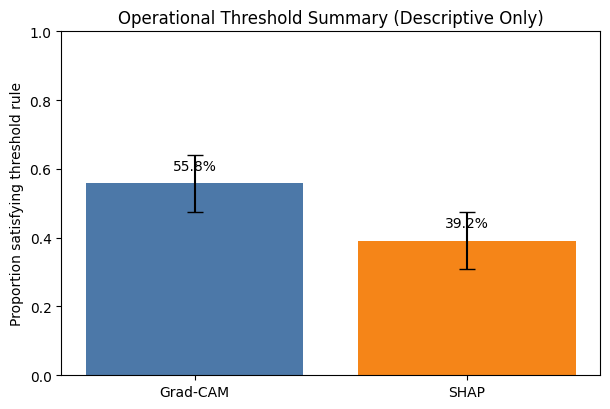

> **Operational threshold summary (descriptive only):** under the project-specific rule `border_ratio ≤ 0.25` AND `Δ_k20 > 0.10`, Grad-CAM > SHAP on pass rate (gap **16.7 pp**, McNemar exact p=**0.0119**).
> **Caution:** the thresholded pass rate compresses continuous evidence, discards magnitude information, and can introduce boundary effects around arbitrary cut-offs; refer to the primary continuous analysis for the main finding.
> **Audit scope:** `all_confidence; max_targets=120` with `N=120` targets.
> **Consistency check:** coverage check: gradcam_missing=0, shap_missing=0; correct/wrong split is provided in Section 7 advanced table.

In [9]:
xai_summary_audit = notebook_load_xai_committee_summary(
    cfg_xai if 'cfg_xai' in globals() else cfg,
    seed=SEED,
    split=EVAL_SPLIT,
)

display(Markdown('### Explanation Quality Comparison'))
display(Markdown('Explanation quality is assessed using complementary continuous dimensions — '
                 'localisation specificity (border ratio, retina ratio) and perturbation-based '
                 'faithfulness (Δ_k20, AOPC) — rather than binary thresholds. Continuous metrics '
                 'preserve magnitude information and avoid boundary effects introduced by arbitrary '
                 'cut-offs.'))

display(Markdown('#### Primary continuous analysis'))
if len(xai_summary_audit.get('continuous_table', [])):
    display(xai_summary_audit['continuous_table'])
    display(Markdown(xai_summary_audit['continuous_bottom_line_markdown']))
else:
    display(Markdown('_Continuous analysis table not found. Re-run cell 15 to generate rq_xai_continuous_*.csv._'))

display(Markdown('#### Secondary: Operational Threshold Summary (Descriptive Only)'))
display(Markdown('A threshold-based operational summary is reported below for descriptive '
                 'completeness only. It is not used as the primary basis for method comparison '
                 'because thresholding compresses continuous evidence, discards magnitude '
                 'information, and can introduce boundary effects around arbitrary cut-offs.'))
display(xai_summary_audit['summary_table'])
display(xai_summary_audit['pass_rate_fig'])
plt.close(xai_summary_audit['pass_rate_fig'])
display(Markdown(xai_summary_audit['bottom_line_markdown']))


In [10]:
if not SHOW_ADVANCED_XAI_AUDIT:
    display(Markdown('_Set `SHOW_ADVANCED_XAI_AUDIT = True` to show descriptive per-class and correctness-split tables._'))
else:
    xai_advanced = notebook_load_xai_advanced_audit(
        cfg_xai if 'cfg_xai' in globals() else cfg,
        seed=SEED,
        split=EVAL_SPLIT,
        xai_outputs=xai_outputs if 'xai_outputs' in globals() else None,
    )

    display(Markdown('### Advanced Descriptive Breakdown'))

    display(Markdown('#### Correct vs Wrong Prediction Split'))
    if len(xai_advanced['correctness_view']):
        display(xai_advanced['correctness_view'])
    else:
        display(Markdown('Unavailable (table not found).'))

    display(Markdown('#### Class-wise Descriptive Explanation Metrics'))
    if len(xai_advanced['classwise_view']):
        display(xai_advanced['classwise_view'])
    else:
        display(Markdown('Unavailable (table not found).'))

    display(Markdown(f"#### Discordant Cases (n={len(xai_advanced['discord_df'])})"))
    if len(xai_advanced['discord_df']):
        display(xai_advanced['discord_df'].head(30))
    else:
        display(Markdown('Unavailable (missing rq1/rq2 columns).'))

    display(Markdown('#### Pairwise Significance'))
    display(xai_advanced['pair_df'] if len(xai_advanced['pair_df']) else pd.DataFrame({'note': ['pairwise table not found']}))

    display(Markdown('#### Runtime Status'))
    display(xai_advanced['status_df'])


_Set `SHOW_ADVANCED_XAI_AUDIT = True` to show descriptive per-class and correctness-split tables._

## 8. Explanation Visual Review


Saved → /Users/sthabit/My Drive/ITPG708Project/artifacts/reports/figures/gradcam_demo_grid.png


**Section 8 settings:** device=auto, shap_background_size=16, shap_images=4

**Manifest used:** `/Users/sthabit/My Drive/ITPG708Project/artifacts/manifests/test_full_aptos2019_85-15-v10_seed1988.csv`

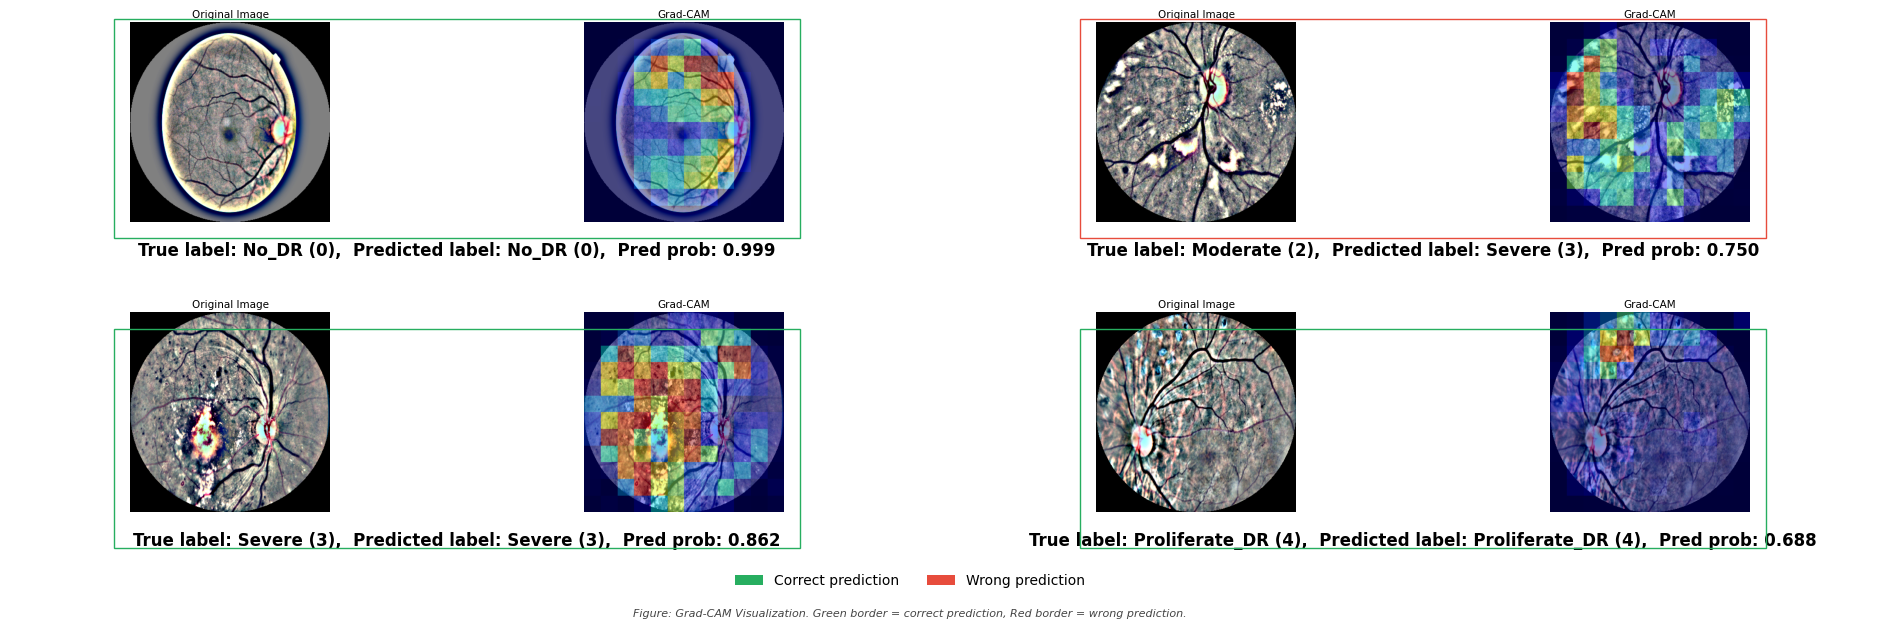

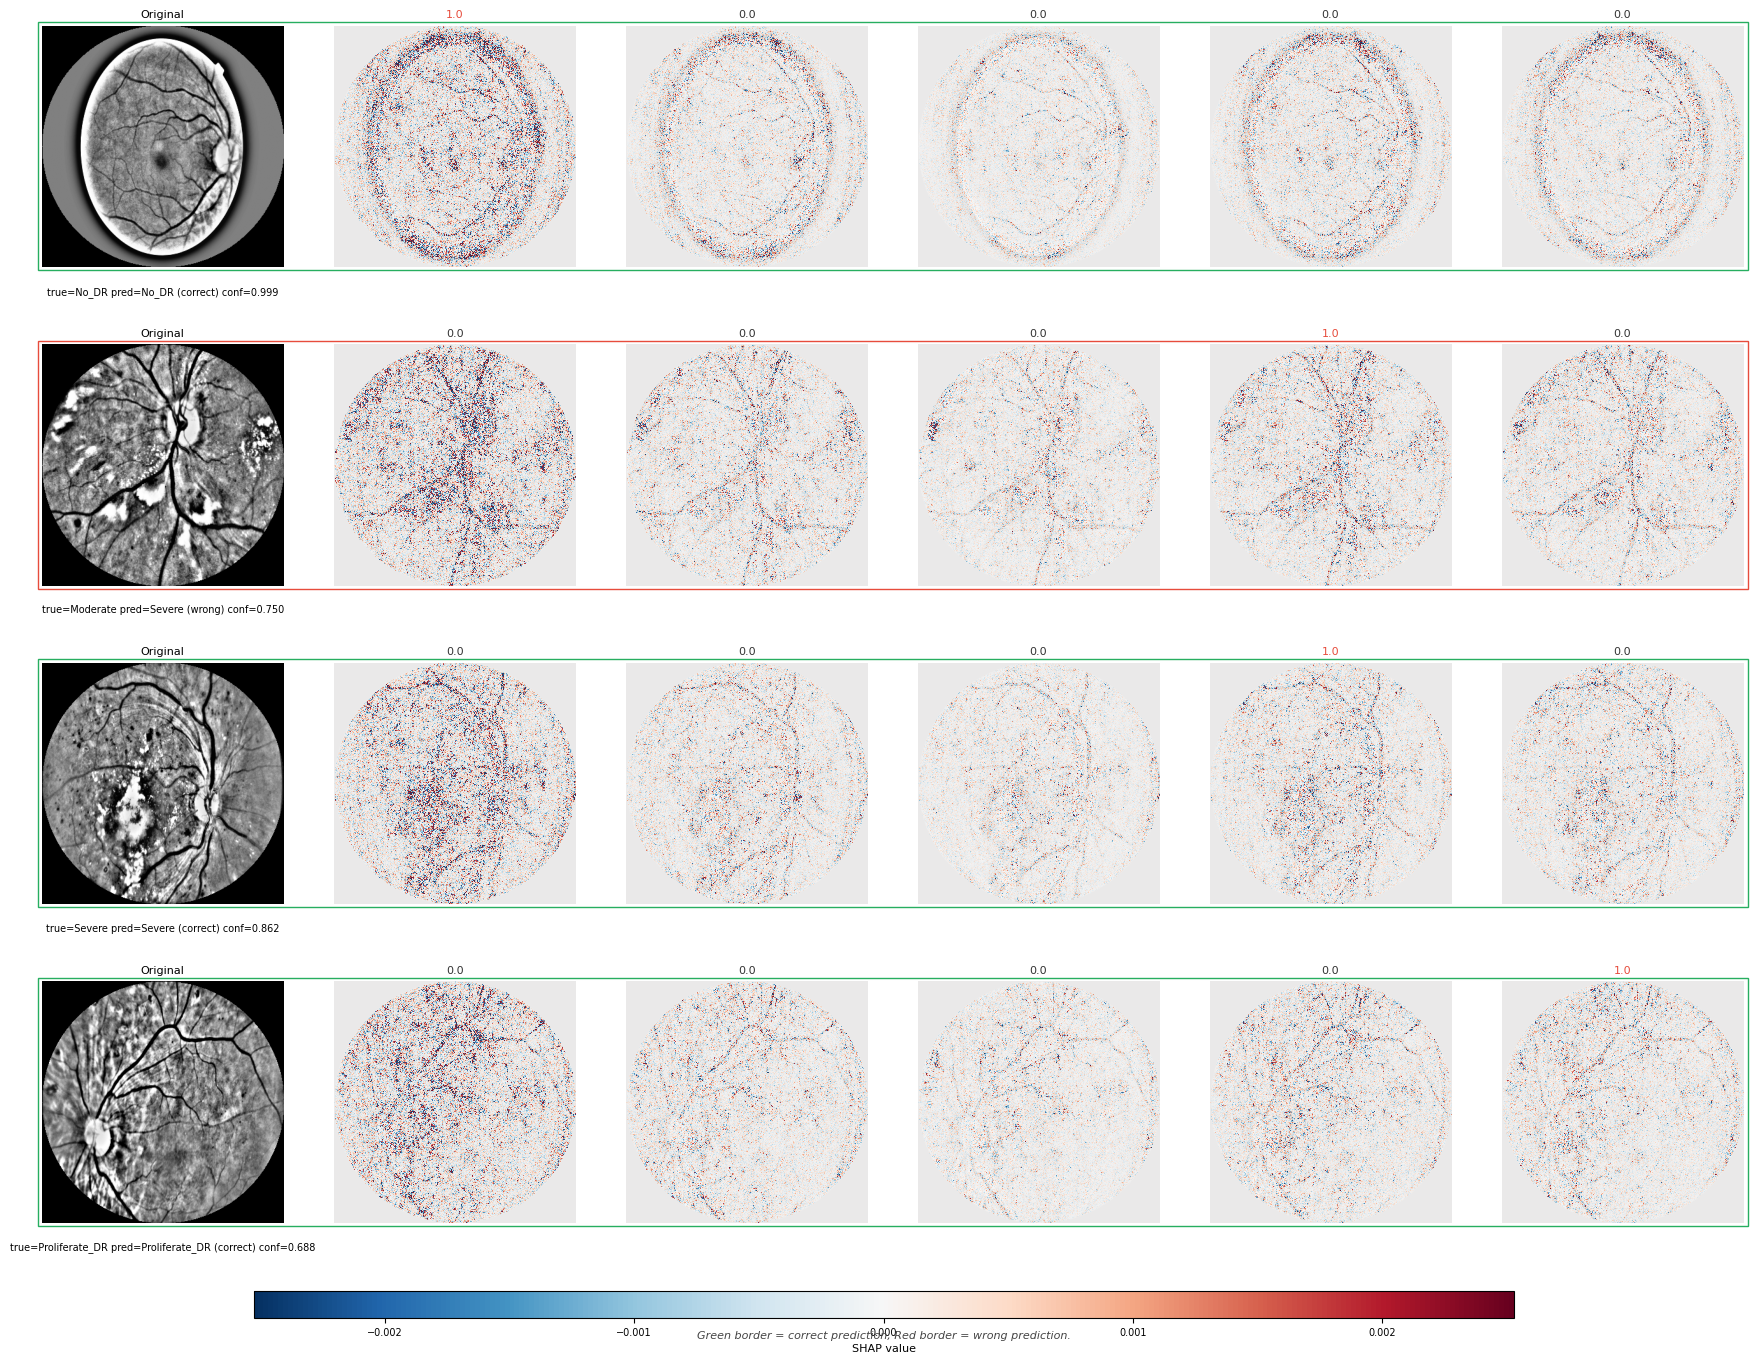

**Section 8 export:** dpi=600, shap_panel_size=(3.0, 3.4), gradcam_pair_size=(6.0, 3.4)

In [11]:
visual_review = notebook_run_visual_review(
    cfg_xai if 'cfg_xai' in globals() else cfg,
    seed=SEED,
    split='test',
    wanted_classes=(0, 2, 3, 4),
    safe_mode=XAI_VIS_SAFE_MODE,
)

display(Markdown(
    f"**Section 8 settings:** device={visual_review['settings']['device']}, "
    f"shap_background_size={visual_review['settings']['shap_background_size']}, "
    f"shap_images={visual_review['settings']['shap_images']}"
))
display(Markdown(f"**Manifest used:** `{visual_review['manifest_path']}`"))

if visual_review['gradcam_fig'] is not None:
    display(visual_review['gradcam_fig'])
    plt.close(visual_review['gradcam_fig'])
else:
    display(Markdown('**Grad-CAM grid unavailable.**'))

if visual_review['shap_fig'] is not None:
    display(visual_review['shap_fig'])
    plt.close(visual_review['shap_fig'])
else:
    display(Markdown('**SHAP grid unavailable.**'))

display(Markdown(
    f"**Section 8 export:** dpi={visual_review['settings']['export_dpi']}, "
    f"shap_panel_size={visual_review['settings']['shap_panel_size']}, "
    f"gradcam_pair_size={visual_review['settings']['gradcam_pair_size']}"
))

if visual_review['warnings']:
    display(Markdown('### Visualization Warnings'))
    for item in visual_review['warnings']:
        display(Markdown(f'- {item}'))


## 9. Single-Case Demonstration


**Manifest used:** `/Users/sthabit/My Drive/ITPG708Project/artifacts/manifests/test_full_aptos2019_85-15-v10_seed1988.csv`

**Image:** `/Users/sthabit/My Drive/ITPG708Project/dataset/aptos2019/train_images/a1edf0e66592.png`

**Prediction:** No_DR (0) | **Confidence:** 0.9878

**True label:** No_DR (0)

**Run ID:** `dr_efficientnet_b4_aptos2019_85-15-v10_seed1988_20260316T0607_9eee8e` | **Device:** `mps`

### Single-Case Probability Distribution

,class_id,class_name,probability
0,0,No_DR,0.987792
1,1,Mild,0.011417
2,2,Moderate,0.000647
3,4,Proliferate_DR,0.000088
4,3,Severe,0.000057


### Clinical Decision Support Narrative
- Predicted DR grade: **No_DR (0)** with probability **0.988**.
- Next most likely alternative: **Mild (0.011)**.
- Suggested triage framing: No DR pattern dominant. Continue routine follow-up if clinical exam is consistent.
- Confidence note: Model confidence is high for this case.
- How to use maps: highlighted regions are decision-support cues, not standalone diagnostic proof.
- Clinical safeguard: final diagnosis and treatment decisions remain clinician-led.

### Explanation Quality Profile

| Method | Border ratio (↓) | Retina ratio (↑) | Δ$_{k20}$ (↑) | AOPC (↑) |
|---|---|---|---|---|
| Grad-CAM | 0.051 | 0.974 | 0.331 | 0.304 |
| SHAP | 0.218 | 0.790 | 0.493 | 0.363 |

**Interpretation:**

- **Border ratio** (↓ lower is better) — share of the heatmap falling on the dark corners outside the eye.
- **Retina ratio** (↑ higher is better) — share landing inside the retinal disc. Low border plus high retina means attention stays on the eye.
- **Δ$_{k20}$** (↑ higher is better) — drop in the model's confidence when the top 20% most-important pixels are removed. A bigger drop means those pixels really mattered to the prediction.
- **AOPC** (↑ higher is better) — the same idea as Δ$_{k20}$ averaged across several removal sizes (a smoother version).

These are per-case decision-support cues, not standalone diagnostic evidence.

### Grad-CAM (Input + Requested Layers)

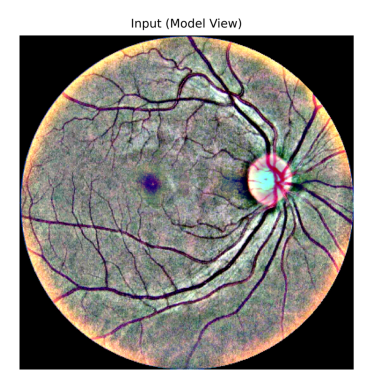

### SHAP (Per-Class Grid)

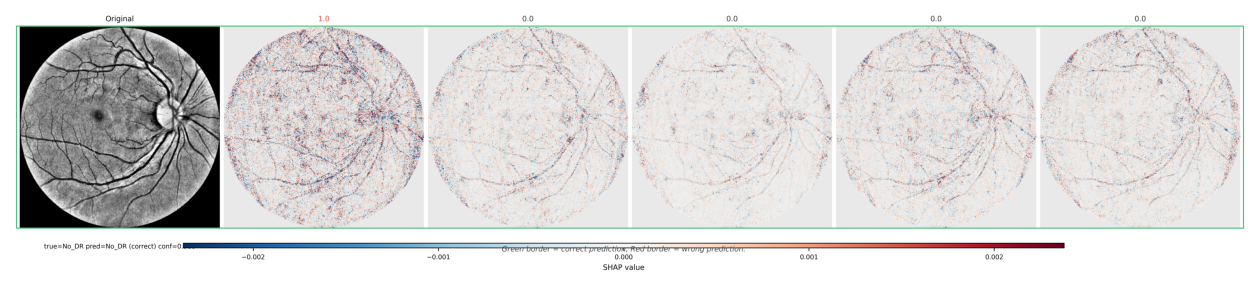

In [12]:
DEMO_IMAGE_PATH = str(globals().get('DEMO_IMAGE_PATH', '')).strip()

single_case = notebook_run_single_case_report(
    cfg_xai if 'cfg_xai' in globals() else cfg,
    seed=SEED,
    image_path=DEMO_IMAGE_PATH,
    split='test',
    safe_mode=XAI_SINGLE_SAFE_MODE,
)

single_demo = single_case['single_demo']

display(Markdown(single_case['summary_markdown']))

display(Markdown('### Single-Case Probability Distribution'))
display(single_case['prob_table'])

display(Markdown(single_case['story_markdown']))

# Explanation quality profile for this single case: same four continuous metrics used
# in the aggregate Section 7 comparison, but computed on the current image only.
if 'quality_profile_markdown' in single_case:
    display(Markdown(single_case['quality_profile_markdown']))

for spec in single_case['figure_sections']:
    display(Markdown(spec['title']))
    fig_path = Path(spec['path'])
    if fig_path.exists():
        plt.figure(figsize=(16, 4.8))
        plt.imshow(plt.imread(fig_path))
        plt.axis('off')
        plt.show()
        plt.close()
    else:
        display(Markdown(f"_Figure not found: `{fig_path}`_"))

if single_case['xai_warnings']:
    display(Markdown('### XAI Warnings'))
    for warning in single_case['xai_warnings']:
        display(Markdown(f'- {warning}'))
